<a href="https://colab.research.google.com/github/SmitSutariya0205/PyTorch-Autoencoders/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
import matplotlib.pyplot as plt


In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from torch.utils.data import DataLoader
BATCH_SIZE=128
data_transform=transforms.Compose([transforms.ToTensor()])

train_dataset=datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=data_transform
)

train_loader=DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE,shuffle=True)

In [4]:
import torch
import torch.nn as nn

latent_dim = 64

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=latent_dim):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps*std
        return z
    def decode(self, z):
        h = self.relu(self.fc2(z))
        out = self.sigmoid(self.fc3(h))
        return out
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar

In [5]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL divergence
    kl_loss = 0.5 * torch.sum(mu**2 + logvar.exp() - logvar - 1)
    return recon_loss + kl_loss

In [6]:
model=VAE().to(device)
optimizer=optim.Adam(model.parameters(),lr = 1e-3)

In [7]:
epochs = 16
model.train()

for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device)
        optimizer.zero_grad()
        x_reconstructed, mu, logvar = model(x)
        loss = vae_loss(x_reconstructed, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/16], Loss: 50.1380
Epoch [2/16], Loss: 38.7855
Epoch [3/16], Loss: 35.6038
Epoch [4/16], Loss: 33.9107
Epoch [5/16], Loss: 32.9478
Epoch [6/16], Loss: 32.3248
Epoch [7/16], Loss: 31.8871
Epoch [8/16], Loss: 31.6000
Epoch [9/16], Loss: 31.3400
Epoch [10/16], Loss: 31.1433
Epoch [11/16], Loss: 30.9698
Epoch [12/16], Loss: 30.8372
Epoch [13/16], Loss: 30.7083
Epoch [14/16], Loss: 30.5959
Epoch [15/16], Loss: 30.5352
Epoch [16/16], Loss: 30.4336


In [8]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(x.size(0), -1).to(device)
    x_recon, _, _ = model(x)
x = x.cpu()
x_recon = x_recon.cpu()

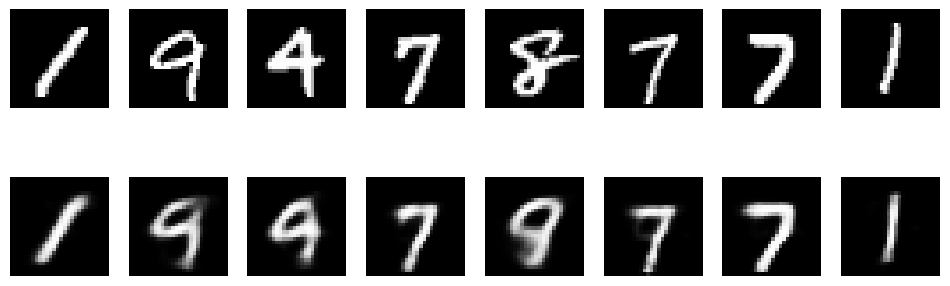

In [9]:
import matplotlib.pyplot as plt

n = 8
plt.figure(figsize=(12,4))

for i in range(n):

    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [10]:
# lets take few random latent vectors and check their reconstruction
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decode(z).cpu()

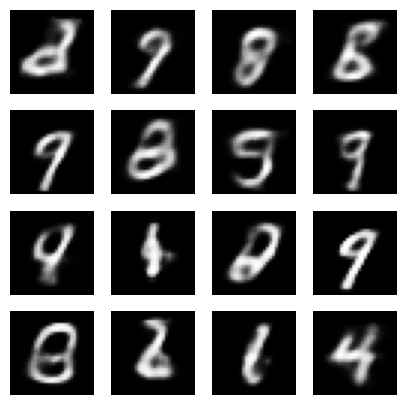

In [11]:
plt.figure(figsize=(5,5))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.show()